#### Import necessary libraries

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

#### Load the dataset

In [2]:
df = pd.read_csv('datasets/SMSSpamCollection', sep='\t', 
                 names=['label','text'])

In [3]:
df

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


#### Separate the input and output variables

In [4]:
x = df['text']
y = df['label']

#### Explore the data

In [5]:
set(y)

{'ham', 'spam'}

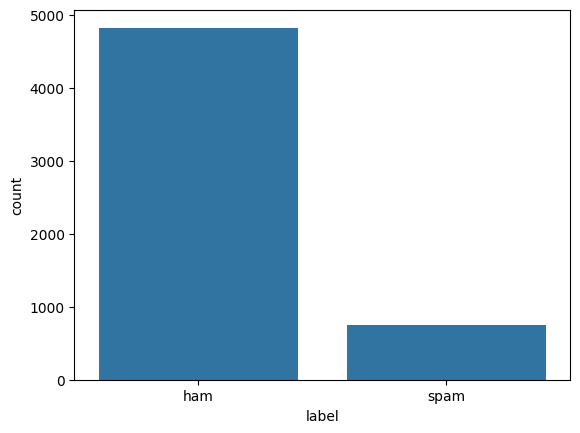

In [6]:
sns.countplot(x = y);

In [7]:
y.value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

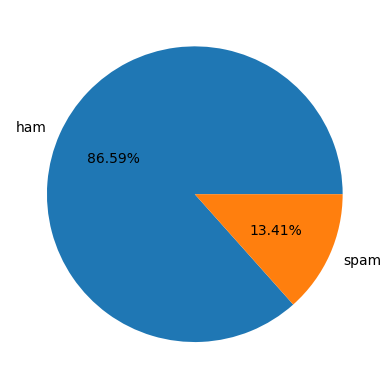

In [8]:
plt.pie(y.value_counts(), 
        labels=y.value_counts().index, autopct='%2.2f%%');

#### Data Preprocessing

##### Data Cleaning

In [9]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import LancasterStemmer, WordNetLemmatizer, PorterStemmer
from nltk import pos_tag

In [10]:
sent = 'Hello friends! How are you? I like Python Programming.'

In [11]:
# tokenize the data 
tokens1 = word_tokenize(sent)

In [12]:
# remove punctuation and numbers 
tokens2 = [token for token in tokens1 if token.isalpha()]

In [13]:
tokens2

['Hello', 'friends', 'How', 'are', 'you', 'I', 'like', 'Python', 'Programming']

In [14]:
# remove stopwords 
tokens3 = [token.lower() for token in tokens2 
           if token.lower() not in stopwords.words('english')]

In [15]:
tokens3

['hello', 'friends', 'like', 'python', 'programming']

In [16]:
# apply stemming 
ps = PorterStemmer()
tokens4 = [ps.stem(token) for token in tokens3] 
tokens4

['hello', 'friend', 'like', 'python', 'program']

In [17]:
def clean_text(sent):
    # tokenize the data 
    tokens1 = word_tokenize(sent)
    # remove punctuation and numbers 
    tokens2 = [token for token in tokens1 if token.isalpha()]
    # remove stopwords 
    tokens3 = [token.lower() for token in tokens2 
           if token.lower() not in stopwords.words('english')]
    tokens4 = [ps.stem(token) for token in tokens3]
    return tokens4

In [18]:
clean_text(sent)

['hello', 'friend', 'like', 'python', 'program']

In [19]:
sent1 = 'It was an unexpected rain during the play on ground.'

In [20]:
clean_text(sent1)

['unexpect', 'rain', 'play', 'ground']

In [21]:
x

0       Go until jurong point, crazy.. Available only ...
1                           Ok lar... Joking wif u oni...
2       Free entry in 2 a wkly comp to win FA Cup fina...
3       U dun say so early hor... U c already then say...
4       Nah I don't think he goes to usf, he lives aro...
                              ...                        
5567    This is the 2nd time we have tried 2 contact u...
5568                 Will ü b going to esplanade fr home?
5569    Pity, * was in mood for that. So...any other s...
5570    The guy did some bitching but I acted like i'd...
5571                           Rofl. Its true to its name
Name: text, Length: 5572, dtype: object

In [22]:
x.apply(clean_text)

0       [go, jurong, point, crazi, avail, bugi, n, gre...
1                            [ok, lar, joke, wif, u, oni]
2       [free, entri, wkli, comp, win, fa, cup, final,...
3           [u, dun, say, earli, hor, u, c, alreadi, say]
4            [nah, think, goe, usf, live, around, though]
                              ...                        
5567    [time, tri, contact, u, pound, prize, claim, e...
5568                       [ü, b, go, esplanad, fr, home]
5569                                [piti, mood, suggest]
5570    [guy, bitch, act, like, interest, buy, someth,...
5571                                   [rofl, true, name]
Name: text, Length: 5572, dtype: object

##### Vectorization

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [24]:
tfidf = TfidfVectorizer(analyzer=clean_text)

In [25]:
x_new = tfidf.fit_transform(x)

In [26]:
x_new.shape

(5572, 5925)

In [27]:
tfidf.get_feature_names_out()

array(['aa', 'aah', 'aaniy', ..., 'zyada', 'é', 'ü'], dtype=object)

In [28]:
len(tfidf.get_feature_names_out())

5925

In [29]:
x_new.toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

#### Cross-Validation

In [30]:
from sklearn.model_selection import train_test_split

In [31]:
x_train, x_test, y_train, y_test = train_test_split(x_new, y, random_state=0)

In [32]:
x_train.shape

(4179, 5925)

In [33]:
x_test.shape

(1393, 5925)

#### Build the model

In [34]:
from sklearn.svm import SVC

In [35]:
svc_lin = SVC(kernel='linear')

In [36]:
svc_lin.fit(x_train, y_train)

SVC(kernel='linear')

#### Performance Evaluation

In [37]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay

In [38]:
y_pred = svc_lin.predict(x_test)

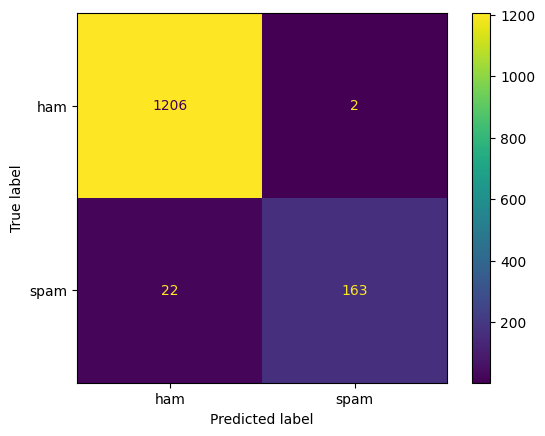

In [39]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

In [40]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         ham       0.98      1.00      0.99      1208
        spam       0.99      0.88      0.93       185

    accuracy                           0.98      1393
   macro avg       0.98      0.94      0.96      1393
weighted avg       0.98      0.98      0.98      1393



In [41]:
accuracy_score(y_test, y_pred)

0.9827709978463748

In [42]:
svc_rbf = SVC(kernel='rbf')
svc_rbf.fit(x_train, y_train)
y_pred = svc_rbf.predict(x_test)
accuracy_score(y_test, y_pred)

0.9813352476669059

In [43]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         ham       0.98      1.00      0.99      1208
        spam       1.00      0.86      0.92       185

    accuracy                           0.98      1393
   macro avg       0.99      0.93      0.96      1393
weighted avg       0.98      0.98      0.98      1393



In [44]:
svc_poly = SVC(kernel='poly')
svc_poly.fit(x_train, y_train)
y_pred = svc_poly.predict(x_test)
accuracy_score(y_test, y_pred)

0.949748743718593

In [45]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         ham       0.95      1.00      0.97      1208
        spam       1.00      0.62      0.77       185

    accuracy                           0.95      1393
   macro avg       0.97      0.81      0.87      1393
weighted avg       0.95      0.95      0.94      1393



In [46]:
svc_sig = SVC(kernel='sigmoid')
svc_sig.fit(x_train, y_train)
y_pred = svc_sig.predict(x_test)
accuracy_score(y_test, y_pred)

0.9798994974874372

In [47]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         ham       0.98      1.00      0.99      1208
        spam       0.98      0.87      0.92       185

    accuracy                           0.98      1393
   macro avg       0.98      0.93      0.95      1393
weighted avg       0.98      0.98      0.98      1393



#### Prediction on unknown data

In [48]:
# sample.csv
# https://mitu.co.in/dataset 

In [49]:
f = open('datasets/sample.csv')
lines= f.readlines()

In [50]:
lines

['Ok lar i double check wif da hair dresser already he said wun cut v short. He said will cut until i look nice.,,\n',
 'As a valued customer, I am pleased to advise you that following recent review of your Mob No. you are awarded with a £1500 Bonus Prize, call 09066364589\n',
 '"Today is ""song dedicated day.."" Which song will u dedicate for me? Send this to all ur valuable frnds but first rply me...",,\n']

In [51]:
new_lines = tfidf.transform(lines)

In [52]:
svc_lin.predict(new_lines)

array(['ham', 'spam', 'ham'], dtype=object)

#### Save the model and preprocessor

In [54]:
import joblib

In [55]:
joblib.dump(svc_lin,'model.bin')

['model.bin']

In [56]:
joblib.dump(tfidf,'preprocess.bin')

['preprocess.bin']